### Chapter 3 — Classification

Working through *Hands-On Machine Learning* Ch. 3 using MNIST.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

#### 1. Load MNIST

70,000 images, 28×28 each, flattened to 784 features. First 60k = train, last 10k = test.

In [16]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target.astype(np.uint8)
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

#### 2. Peek at a digit

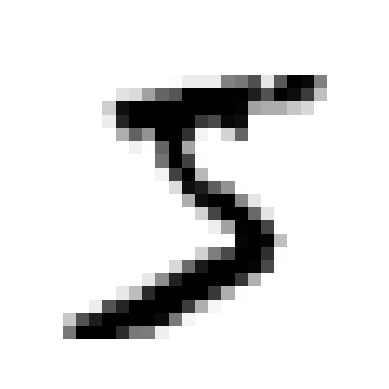

In [17]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

#### 3. Binary classifier — "is it a 5?"

Reframe labels as True/False, then train an SGDClassifier.

##### What `SGDClassifier.fit()` does under the hood

Before running the fit, the algorithm it implements:

```
1. Initialize w randomly (tiny numbers, ~0)
2. For each epoch (pass over the dataset):
     For each training example (x_i, y_i):
        a. score    = w · x_i + b
        b. loss     = how wrong the score is given y_i
        c. gradient = ∂loss/∂w
        d. w  ←  w − η · gradient
3. Stop when loss stops improving (or after max_iter epochs)
4. Freeze the final w (stored as sgd_clf.coef_)
```

One epoch = one full pass through all 60,000 training images, one update per image. Pure SGD, no batching.

---

###### Worked numerical example (4 pixels instead of 784)

Shrinking the image from 28×28 to 2×2 makes the arithmetic tractable; every step scales up identically to MNIST.

**Setup**

```
pixel layout (2×2):       values (normalized 0–1):
┌─────┬─────┐             ┌─────┬─────┐
│  1  │  2  │             │ 0.9 │ 0.1 │    ← ink, blank
├─────┼─────┤             ├─────┼─────┤
│  3  │  4  │             │ 0.8 │ 0.9 │    ← ink, ink
└─────┴─────┘             └─────┴─────┘

Flattened:  x = [0.9, 0.1, 0.8, 0.9]
True label: y = 1  (yes, it's a 5)   →  y_signed = +1
Hyperparameters:  η = 0.1,  b = 0
```

**Loss function — hinge loss** (what `SGDClassifier` uses by default)

```
L = max(0, 1 − y_signed · score)
```

- Zero loss only when `y_signed · score ≥ 1` — confidently correct.
- Gradient (when loss > 0):  `∂L/∂w = −y_signed · x`
- Gradient when loss = 0:  zero → no update.

---

###### Scenario A — confidently correct

```
w = [1.0, -0.5, 0.8, 0.6]

score = 1.0·0.9 + (-0.5)·0.1 + 0.8·0.8 + 0.6·0.9
      = 0.90  − 0.05  + 0.64  + 0.54
      = 2.03

prediction = +1 (is a 5)  ✅
loss       = max(0, 1 − 2.03) = 0
gradient   = 0  →  no update,  w unchanged
```

Model is confidently correct. SGD does nothing — no reason to fix what isn't broken.

---

###### Scenario B — confidently wrong

```
w = [-0.8, 0.5, -0.6, -0.4]

score = -0.72 + 0.05 − 0.48 − 0.36  =  -1.51
prediction = −1 (not a 5)  ❌
loss       = max(0, 1 − (−1.51)) = 2.51      ← big

gradient   = −(+1) · [0.9, 0.1, 0.8, 0.9]
           = [−0.9, −0.1, −0.8, −0.9]

w_new = w − η · gradient
      = [-0.8, 0.5, -0.6, -0.4]  −  [-0.09, -0.01, -0.08, -0.09]
      = [-0.71, 0.51, -0.52, -0.31]

Rescore same image with new w:
new score = -0.639 + 0.051 − 0.416 − 0.279  =  -1.28
new loss  = 2.28      ← down from 2.51  ✅
```

Still wrong, but less wrong. A few more images like this and the "ink" weights flip positive.

---

###### Scenario C — borderline (right, but not confident)

```
w = [0.2, -0.1, 0.3, 0.2]

score = 0.18 − 0.01 + 0.24 + 0.18  =  0.59
prediction = +1 (is a 5)  ✅
loss       = max(0, 1 − 0.59) = 0.41     ← nonzero because score < 1

gradient = [-0.9, -0.1, -0.8, -0.9]
w_new    = [0.29, -0.09, 0.38, 0.29]

Rescore same image with new w:
new score = 0.817
new loss  = 0.183     ← down from 0.41  ✅
```

Model is right but hedged — hinge loss demands `score ≥ 1` before it stops nudging, so the decision gets sharpened.

---

###### Summary

| Scenario | Score | Prediction | Loss | Gradient fires? | Effect |
|----------|------:|:----------:|-----:|:---------------:|--------|
| **A. Confident right** | +2.03 | ✅ | 0 | No | `w` unchanged |
| **B. Confident wrong** | −1.51 | ❌ | 2.51 | Yes (big) | Shift firmly toward "ink = 5" |
| **C. Borderline right** | +0.59 | ✅ | 0.41 | Yes (small) | Sharpen the decision |

**What to carry forward**

1. **Score's sign = prediction. Score's magnitude = confidence.**
2. Hinge loss only silences the gradient when the model is confidently correct — good-enough-right still gets nudged.
3. Direction of the nudge (after the minus sign): **move `w` toward `x` when label is +1, away from `x` when label is −1.** Repeat 60,000 times per epoch and `w` becomes the learned "template of 5."
4. Blowing the 4-element vectors up to 784 elements and running for many epochs is exactly what `SGDClassifier.fit(X_train, y_train_5)` does.

In [18]:
y_train_5 = (y_train == 5)

In [19]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [20]:
sgd_clf.predict([some_digit])

array([ True])

#### 4. Performance measures

Accuracy alone won't tell us whether our "is it a 5?" classifier actually works. This section builds up the honest picture — confusion matrix, precision, recall, and F1 — and shows what each metric reveals that accuracy hides.

##### 4.1 Accuracy via cross-validation

`cross_val_score` runs K-fold CV: train on `K-1` folds, evaluate on the held-out fold, repeat `K` times. The returned array has one accuracy per fold.

In [21]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

The numbers look great — ~95–96% — but read them carefully.

**Only ~10% of MNIST images are actually 5s.** A classifier that *always* predicts "not 5" — ignoring the pixels — would score ~90% out of the box. Our model's real lift over that dumb baseline is only 5–6 percentage points.

Accuracy is the wrong first-look metric whenever classes are imbalanced. It conflates two very different failure modes:
- Saying "5" when the image isn't one (**false alarms**)
- Saying "not 5" when it is (**missed detections**)

To see those separately, we need the confusion matrix.

##### 4.2 Confusion matrix

The confusion matrix is a 2×2 grid that keeps all four outcome counts instead of collapsing them into one number:

```
                    Predicted
                 Negative    Positive
Actual  Negative    TN          FP
        Positive    FN          TP
```

- **TN** (True Negative) — correctly said "not 5"
- **FP** (False Positive) — said "5", wasn't. *False alarm.*
- **FN** (False Negative) — said "not 5", was. *Missed detection.*
- **TP** (True Positive) — correctly caught a 5

**Mnemonic:** first letter (T/F) = was the model right? Second letter (P/N) = what did it say? So "False Negative" = said Negative, was wrong → missed a real positive.

To compute this honestly we need predictions for *every* training example without any training on that example (avoiding data leakage). `cross_val_predict` does exactly this — uses K-fold CV and returns the predictions themselves instead of a score.

In [22]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

Reading the matrix layout (`sklearn` convention):

```
[[TN, FP],
 [FN, TP]]
```

- **TN** — non-5 images correctly marked as not-5
- **FP** — non-5 images falsely flagged as 5 (**false alarms**)
- **FN** — real 5s that were missed (**misses**)
- **TP** — real 5s correctly caught

If the model were perfect, the off-diagonal cells (FP and FN) would be zero. Whichever off-diagonal is larger tells you which error your model makes more often. Eyeball our `cm` output — you should see FN > FP, meaning the classifier misses more 5s than it falsely flags.

##### 4.3 Precision and recall

Four raw counts are hard to compare across models. Two derived metrics summarize the confusion matrix, each answering a specific question.

**Precision**

```
precision = TP / (TP + FP)
```

Of everything your model **said was positive**, what fraction really were?

- Denominator = your positive predictions
- Punishes: false alarms (FP)
- Goes up when the model is **selective** — only calls things "5" when very sure

**Recall** (also called *sensitivity* or *true positive rate*)

```
recall = TP / (TP + FN)
```

Of the **actual positives** in the data, what fraction did your model catch?

- Denominator = real positives that exist
- Punishes: missed detections (FN)
- Goes up when the model is **thorough** — rarely lets a real 5 slip through

**The asymmetry — why you can't just maximize one**

You can trivially get 100% precision: only predict "5" for the *one* image you're most confident about. Everything else, predict "not 5." You'll be right on that single prediction (P=1.0) but miss thousands of real 5s (R≈0).

You can trivially get 100% recall: predict "5" for **every** image. You'll catch every real 5 (R=1.0) but have thousands of false alarms (P≈0.1).

Real classifiers sit somewhere in the middle — raising one tends to lower the other. This is the **precision–recall tradeoff**, controlled by the decision threshold (next section).

**When to prefer which**

| Scenario | Prefer | Why |
|----------|--------|-----|
| Cancer screening | **Recall** | Missed disease is catastrophic |
| Security / fraud alerts | **Recall** | False alarm is cheap, miss is not |
| Spam filter | **Precision** | Don't bury legitimate email |
| Criminal conviction | **Precision** | Don't punish the innocent |
| Medical surgery eligibility | **Precision** | Operating on someone who didn't need it is harmful |
| "Roughly balanced" | **F1** (both) | Use when cost is symmetric or unknown |

In [24]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y_train_5, y_train_pred)
recall    = recall_score(y_train_5, y_train_pred)

print(f'precision = {precision:.3f}')
print(f'recall    = {recall:.3f}')

precision = 0.837
recall    = 0.651


**Reading our numbers:**

- Precision = **0.837** → when the model flags a 5, it's right 83.7% of the time.
- Recall = **0.651** → the model only catches 65% of the actual 5s — it misses more than a third.

**Translation:** our classifier is **cautious**. Rarely cries wolf (few false alarms), but lets many real 5s slip through. You now know:

- The 96% accuracy was hiding this — most of that came from correctly labeling non-5s.
- If missing a 5 is costly (e.g., an OCR pipeline where every 5 must be captured), we have a problem.
- If a false alarm is costly (e.g., each flagged 5 triggers expensive downstream review), we're actually doing well.

Which matters depends on the downstream use. Accuracy never forces you to ask that question; precision and recall do.

##### 4.4 F1 score — the harmonic mean

Often you want **one** number that summarizes both precision and recall. F1 is the standard choice:

```
F1 = 2 · (P · R) / (P + R)
```

This is the **harmonic mean** of P and R, not the ordinary (arithmetic) mean. The distinction matters.

**Why harmonic, not arithmetic?**

Arithmetic mean treats P and R symmetrically: raising one by 0.1 offsets lowering the other by 0.1. That's the wrong model — a classifier with P=1.0 and R=0.0 catches no real positives at all, yet arithmetic mean would call it "0.5" (halfway decent).

The harmonic mean is **dominated by the smaller value**. If either metric is near zero, F1 is near zero, regardless of how high the other is.

**Numerical contrast:**

| P | R | Arithmetic mean | F1 (harmonic) |
|---|---|:---:|:---:|
| 0.9 | 0.9 | 0.90 | **0.90** |
| 0.9 | 0.1 | 0.50 | **0.18** |
| 1.0 | 0.0 | 0.50 | **0.00** |
| 0.5 | 0.5 | 0.50 | **0.50** |
| 1.0 | 0.5 | 0.75 | **0.67** |

F1 only rewards classifiers that are **genuinely good at both**. You can't game F1 by maxing out one metric.

**When NOT to use F1**

F1 implicitly assumes precision and recall matter equally. When they don't — cancer screening cares far more about recall, spam filters far more about precision — F1 is misleading. In those cases either weight them (the **Fβ** score, where β > 1 emphasizes recall, β < 1 emphasizes precision) or report both numbers and pick an operating point explicitly.

In [25]:
from sklearn.metrics import f1_score

f1 = f1_score(y_train_5, y_train_pred)

print(f'F1 = {f1:.3f}')

F1 = 0.733


**Reading our F1:** ~0.73.

Sanity check against the formula: `2 · 0.837 · 0.651 / (0.837 + 0.651) ≈ 0.732`. ✓

Compare what each metric reported:

| Metric | Value | Narrative |
|--------|------:|-----------|
| Accuracy  | 0.96 | "Great" — but floor is 0.90 |
| Precision | 0.84 | "Good" — few false alarms |
| Recall    | 0.65 | "Meh" — misses 35% of real 5s |
| **F1**    | **0.73** | **Honest summary** — recall drag pulls it down |

The arithmetic mean of 0.84 and 0.65 is 0.745 — barely different from F1 here because the two metrics aren't that far apart. Where harmonic vs arithmetic diverges sharply is when one metric is much worse than the other (see the 0.9/0.1 row in the table above, where F1 crashes to 0.18 while arithmetic stays at 0.50).

**What this tells us about the classifier:** it's cautious by default. `SGDClassifier` computes a real-valued score and thresholds at 0 when calling `.predict()`. Moving that threshold up or down shifts precision and recall against each other — the **precision–recall tradeoff**. That's the next section: choosing an operating point instead of accepting the default.

In [26]:
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]

print(f"threshold for 90% precision = {threshold_for_90_precision:.2f}")
print(f"recall at that threshold    = {recalls[idx_for_90_precision]:.3f}")

threshold for 90% precision = 3370.02
recall at that threshold    = 0.480


##### 4.7 ROC-AUC vs PR-AUC — a visual comparison

Two scalar summaries of the same threshold sweep, computed from the same `y_scores`:

- **ROC-AUC** — area under the ROC curve (x: FPR, y: TPR). Intuition: the probability that a random positive scores higher than a random negative. Range `[0, 1]`; `0.5` = random, `1.0` = perfect separation.
- **PR-AUC** — area under the PR curve (x: recall, y: precision), also called *average precision* (`AP`). Range `[P(positive), 1]`; the baseline is the **positive class base rate**, not 0.5. For MNIST-is-5 that baseline is ≈ 0.09.

###### How to read the plot below

- **ROC (left)** — perfect classifier hugs the top-left corner. Diagonal dotted line = random. Our classifier's curve looks near-ideal. Don't be fooled — the huge `TN` pool inflates the visual.
- **PR (right)** — perfect classifier hugs the top-right corner. Horizontal dotted line = random baseline at 9% (the positive rate). Our PR curve clearly sags below top-right — there is real room to improve.
- **Black dot** on each — the same operating point (threshold for 90% precision) marked on both curves. Same model, same threshold; the dot's apparent "quality" differs purely because the axes differ.

###### Takeaway

On imbalanced data, ROC flatters; PR tells the truth. For any imbalanced classification problem, report both AUCs and let PR drive model selection.

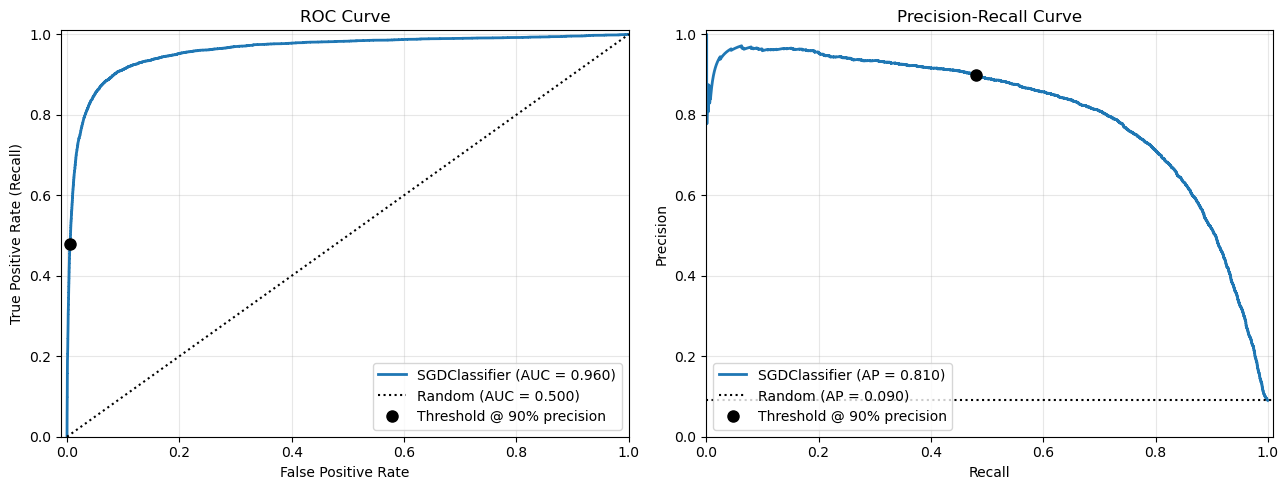

ROC-AUC = 0.960   (baseline 0.500)
PR-AUC  = 0.810   (baseline 0.090)


In [28]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

roc_fpr, roc_tpr, roc_thresholds = roc_curve(y_train_5, y_scores)
roc_auc   = roc_auc_score(y_train_5, y_scores)
pr_auc    = average_precision_score(y_train_5, y_scores)
base_rate = y_train_5.mean()

# Same operating point — threshold at 90% precision — marked on both curves
pr_idx  = idx_for_90_precision
roc_idx = (roc_thresholds <= threshold_for_90_precision).argmax()

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
ax_roc.plot(roc_fpr, roc_tpr, linewidth=2,
            label=f"SGDClassifier (AUC = {roc_auc:.3f})")
ax_roc.plot([0, 1], [0, 1], "k:", label="Random (AUC = 0.500)")
ax_roc.plot(roc_fpr[roc_idx], roc_tpr[roc_idx], "ko", markersize=8,
            label="Threshold @ 90% precision")
ax_roc.set(xlabel="False Positive Rate",
           ylabel="True Positive Rate (Recall)",
           title="ROC Curve",
           xlim=(-0.01, 1.0), ylim=(0.0, 1.01))
ax_roc.grid(alpha=0.3)
ax_roc.legend(loc="lower right")

# PR curve
ax_pr.plot(recalls, precisions, linewidth=2,
           label=f"SGDClassifier (AP = {pr_auc:.3f})")
ax_pr.axhline(base_rate, color="k", linestyle=":",
              label=f"Random (AP = {base_rate:.3f})")
ax_pr.plot(recalls[pr_idx], precisions[pr_idx], "ko", markersize=8,
           label="Threshold @ 90% precision")
ax_pr.set(xlabel="Recall", ylabel="Precision",
          title="Precision-Recall Curve",
          xlim=(0.0, 1.01), ylim=(0.0, 1.01))
ax_pr.grid(alpha=0.3)
ax_pr.legend(loc="lower left")

plt.tight_layout()
plt.show()

print(f"ROC-AUC = {roc_auc:.3f}   (baseline 0.500)")
print(f"PR-AUC  = {pr_auc:.3f}   (baseline {base_rate:.3f})")

##### 4.8 Random Forest — same eval flow, new model

The payoff of the metrics framework: once it's in place, swapping models is cheap. Below, `RandomForestClassifier` runs through the same pipeline (`cross_val_predict` → PR curve → F1 → ROC-AUC) with two small differences worth noting.

###### Two things change for RF

- **No `decision_function`.** RF isn't score-based — each tree votes, and `predict_proba` returns the fraction of trees voting positive. Use `method="predict_proba"` and grab column 1 (positive-class probabilities).
- **Threshold convention shifts.** The "natural default" threshold is now **0.5** (probability), not **0** (decision score). Same idea, different scale.

###### What to watch for

RF should comfortably beat SGD here — tree ensembles handle nonlinear pixel patterns that a single linear separator can't. Look for the RF PR curve sitting visibly closer to the top-right corner, and all three scalar metrics (F1, ROC-AUC, PR-AUC) stepping up.

Note: `cross_val_predict` with RF will take a minute or two — it's fitting 3 forests on 40k images each.

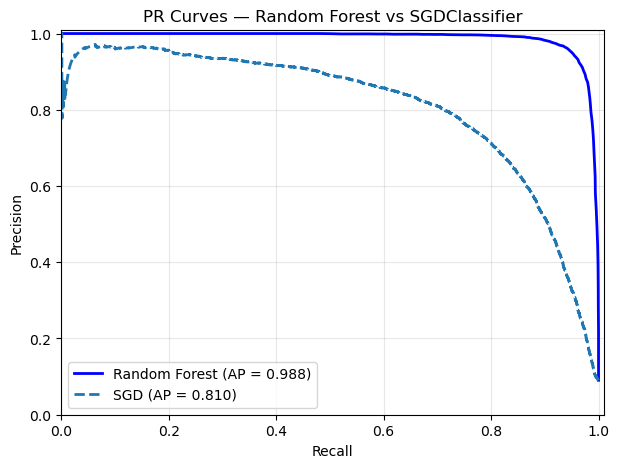

F1       — SGD: 0.733   RF: 0.927
ROC-AUC  — SGD: 0.960   RF: 0.998
PR-AUC   — SGD: 0.810   RF: 0.988


In [29]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

# RF gives probabilities, not decision scores — grab the positive-class column
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]

# PR curve arrays for RF
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest
)

# Scalar metrics at default 0.5 threshold
y_train_pred_forest = y_scores_forest >= 0.5
f1_forest      = f1_score(y_train_5, y_train_pred_forest)
roc_auc_forest = roc_auc_score(y_train_5, y_scores_forest)
pr_auc_forest  = average_precision_score(y_train_5, y_scores_forest)

# Compare PR curves
plt.figure(figsize=(7, 5))
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label=f"Random Forest (AP = {pr_auc_forest:.3f})")
plt.plot(recalls, precisions, "--", linewidth=2,
         label=f"SGD (AP = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curves — Random Forest vs SGDClassifier")
plt.xlim(0, 1.01)
plt.ylim(0, 1.01)
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.show()

print(f"F1       — SGD: {f1:.3f}   RF: {f1_forest:.3f}")
print(f"ROC-AUC  — SGD: {roc_auc:.3f}   RF: {roc_auc_forest:.3f}")
print(f"PR-AUC   — SGD: {pr_auc:.3f}   RF: {pr_auc_forest:.3f}")

##### 4.9 Recap — the binary-classifier mental model

A single reference block for everything covered in §3–§4. Re-read this before starting multiclass.

###### The setup

- **Dataset:** MNIST, 60k training images (28×28 = 784 pixels).
- **Problem transform:** collapsed 10 classes → `y = True/False` ("is it a 5?").
- **Imbalance baked in:** ~9% are 5s, ~91% are not-5s. This imbalance drives nearly every metric choice downstream.

###### Core mental model

> **Every binary classifier is a ranking machine.**

For each image, the classifier produces **one score**. Everything else — predictions, metrics, curves — is built from those scores.

```
image → classifier → one number (score) → compare to threshold → True/False
```

The score's *source* differs by model, but the machinery is identical:

| Model | Method | Score meaning | Range | Default threshold |
|---|---|---|---|---|
| SGD | `decision_function` | Signed distance from hyperplane | Unbounded | 0 |
| Random Forest | `predict_proba[:, 1]` | Fraction of trees voting "5" | [0, 1] | 0.5 |

Once you have scores, the model is interchangeable — PR curve, ROC curve, F1 all work the same way.

###### The confusion matrix — source of all metrics

At any given threshold, four buckets:

|  | Predicted: 5 | Predicted: not-5 |
|---|---|---|
| **Actually 5** | TP (true positive) | FN (false negative) |
| **Actually not-5** | FP (false positive) | TN (true negative) |

Every metric below is built from these four numbers. Memorize this grid and you can re-derive everything.

###### The derived metrics

| Metric | Formula | Plain English | When you care |
|---|---|---|---|
| **Precision** | TP / (TP + FP) | "Of images I flagged as 5, what fraction really are?" | Cost of a false alarm is high |
| **Recall** (TPR) | TP / (TP + FN) | "Of all real 5s, what fraction did I catch?" | Cost of a miss is high |
| **F1** | 2·P·R / (P + R) | Harmonic mean — pulled low by the weaker of the two | You want one balanced number |
| **FPR** | FP / (FP + TN) | "Of real not-5s, what fraction did I wrongly flag?" | ROC only; dangerously optimistic when imbalanced |

**Why harmonic mean for F1?** Punishes imbalance. If P = 1.0 and R = 0.01, arithmetic mean = 0.505 (misleadingly okay), but F1 ≈ 0.02 (honestly terrible).

###### The threshold knob — precision/recall tradeoff

Sliding the threshold trades precision against recall:

```
threshold → very high          threshold → very low
"only shout '5!' if              "shout '5!' at anything
 I'm super certain"               remotely 5-ish"

precision: high                  precision: low
recall:    low                   recall:    high
```

**You cannot improve both simultaneously** with the *same* model. Improving both requires a *better* model (e.g., SGD → RF moved the whole curve up and to the right).

**Operating-point picking:** real projects fix one metric at a business requirement ("we need ≥90% precision") and read the achievable other ("that gets us 48% recall"). Not "maximize F1 in a vacuum".

###### The two curves

Every point on either curve = one threshold choice.

| Curve | X-axis | Y-axis | What it shows |
|---|---|---|---|
| **PR curve** | Recall | Precision | How precision degrades as you push to catch more 5s |
| **ROC curve** | FPR | TPR (= recall) | How false-alarm rate rises as you push to catch more 5s |

**Perfect classifier:** PR hugs top edge with cliff at recall = 1.0; ROC hugs top-left corner.

**Random classifier:** PR is a horizontal line at base rate (≈ 0.09 for 5s); ROC is the diagonal.

###### The AUCs

Single-number summaries of the full curve.

| AUC | What it means | Baseline | Best |
|---|---|---|---|
| **ROC-AUC** | P(random positive scored higher than random negative) | 0.5 | 1.0 |
| **PR-AUC** (average precision) | Average precision across all recall levels | = base rate (≈0.09) | 1.0 |

**Key insight from §4.7–§4.8:**

```
                    ROC-AUC    PR-AUC    Gap
SGD                  0.960      0.810    0.15  ← imbalance inflation
Random Forest        0.998      0.988    0.01  ← genuinely strong model
```

**When ROC-AUC ≫ PR-AUC, the ROC number is lying to you** — the huge TN pool is inflating it. Trust PR-AUC for imbalanced problems.

###### Evaluation hygiene — `cross_val_predict`

Never evaluate a classifier on data it trained on. That leaks truth into the scores and gives fantasy metrics.

`cross_val_predict` splits training data into k folds, trains on k−1, predicts the held-out fold, repeats. Every training point gets a score from a model that *didn't see it* during training. Honest scores → honest curves.

This is why the same `y_scores` is reused across evaluation cells — it's the one honest batch of SGD scores on the training set.

###### Calibration note (RF only)

RF's `predict_proba` numbers look like probabilities but aren't literally so. "88/100 trees voted yes" ≠ "88% real-world probability." Trees are overconfident near 0 and 1. For **ranking/thresholding** (what we've been doing), this doesn't matter. For **decision-making with costs** (expected value, combining with other systems), wrap in `CalibratedClassifierCV`.

###### Mental checklist for any binary problem

1. **What's the base rate?** (Imbalance check.)
2. **What's the cost of FP vs FN?** (Picks between precision and recall.)
3. **Get honest scores** via `cross_val_predict`.
4. **Plot PR curve** (primary for imbalanced) and **ROC curve** (secondary).
5. **Read off the AUCs.** If PR-AUC ≪ ROC-AUC, your model is worse than ROC suggests.
6. **Pick an operating threshold** based on a business constraint, not "where F1 is maximized".
7. **Re-evaluate on test set** only once, at the end, with the chosen threshold.

###### Teaser — what changes for multiclass?

The score-per-class idea generalizes. Instead of one score per image, you get **ten** — one per digit. Two strategies sklearn auto-picks between:

- **OvR (One-vs-Rest):** train 10 binary classifiers ("is it 0?", …, "is it 9?"). Pick the class with the highest score. *This is literally what we did today, ten times.*
- **OvO (One-vs-One):** train 45 binary classifiers, one per pair. Each prediction is a voting round.

**What stays the same:** `decision_function` / `predict_proba` still exist, still return scores, still threshold-able.

**What changes:** the confusion matrix becomes 10×10. Precision/recall/F1 become per-class, then averaged (macro vs micro vs weighted). PR and ROC curves require either per-class plots or a micro/macro average — the "one curve" story gets bumpier.

The mental model survives: **still a ranking machine, still scores + thresholds + confusion matrix** — just ten channels instead of one.
